In [5]:
%pip install pandas openpyxl matplotlib scikit-learn anthropic

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached anthropic-0.76.0-py3-none-any.whl.metadata (28 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached docstring_parser-0.17.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 15.4 MB/s  0:00:00 eta 0:00:01
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 15.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 10.8 MB/s  0:00:00 eta 0:00:01
Usi

# Car Data Analysis - 3 Ways to Use Claude

This notebook demonstrates three approaches:
- **Option A**: Copy data to Claude Code (already done in terminal)
- **Option B**: Manual pandas analysis with Claude-suggested code
- **Option C**: Using Anthropic API directly in notebook

## Setup & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the car dataset
df = pd.read_excel('car-data.xlsx')
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head()

Matplotlib is building the font cache; this may take a moment.


Loaded 7,601 rows, 21 columns


,Title Description,Year,Make,Model,Trim,Price,Mileage,Car Type,Sales Type,Body,...,Interior Condition,Exterior Color,Interior Color,Transmission,Drive Type,Title Type,Fuel Type,Number of Doors,Liters,Cylinders
0,2010 Honda Accord LX,2010,Honda,Accord,LX,9200,102000,Used Car,For Sale By Owner,Sedan,...,Very Good,Silver,Gray,Automatic,2-Wheel Drive,Clean Title,Gasoline,4.0,NaN,4.0
1,2006 Ford F-150 Lariat,2006,Ford,F-150,Lariat,4500,341000,Used Car,For Sale By Owner,Truck,...,Good,Gray,Tan,Automatic,4-Wheel Drive,Clean Title,Gasoline,4.0,5.4,8.0
2,1999 Ford Taurus SE Comfort,1999,Ford,Taurus,SE Comfort,1100,183417,Used Car,For Sale By Owner,Sedan,...,Good,Red,Beige,Automatic,FWD,Clean Title,Gasoline,4.0,3,6.0
3,2000 Dodge Ram 1500 SLT,2000,Dodge,Ram 1500,SLT,9400,49000,Used Car,For Sale By Owner,Truck,...,Excellent,White,Gray,Automanual,4-Wheel Drive,Clean Title,Gasoline,4.0,5.2,8.0
4,2016 Toyota 4Runner TRD Pro,2016,Toyota,4Runner,TRD Pro,48000,12000,Used Car,For Sale By Owner,Sport Utility,...,Excellent,Brown,Black,Automatic,4-Wheel Drive,Clean Title,Gasoline,5.0,NaN,6.0


---
## Option B: Manual Analysis (Claude-Suggested Code)

Run these cells to clean and analyze the data.

In [7]:
# B1: Data Overview
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing': missing, 'Percent': missing_pct}).query('Missing > 0').sort_values('Missing', ascending=False)

=== Dataset Shape ===
Rows: 7,601
Columns: 21

=== Data Types ===
Title Description         str
Year                    int64
Make                      str
Model                     str
Trim                      str
Price                   int64
Mileage                 int64
Car Type                  str
Sales Type                str
Body                      str
Exterior Condition        str
Interior Condition        str
Exterior Color            str
Interior Color            str
Transmission              str
Drive Type                str
Title Type                str
Fuel Type                 str
Number of Doors       float64
Liters                    str
Cylinders             float64
dtype: object

=== Missing Values ===


,Missing,Percent
Liters,4058,53.4
Interior Condition,2630,34.6
Exterior Condition,2629,34.6
Trim,1725,22.7
Number of Doors,1673,22.0
Interior Color,1165,15.3
Drive Type,754,9.9
Transmission,730,9.6
Exterior Color,467,6.1
Cylinders,86,1.1


In [8]:
# B2: Clean the Data
df_clean = df.copy()

# Remove mileage outliers (likely data entry errors)
print(f"Before mileage filter: {len(df_clean):,} rows")
df_clean = df_clean[df_clean['Mileage'] < 500000]
print(f"After mileage filter: {len(df_clean):,} rows")

# Fill missing categorical values
df_clean['Trim'] = df_clean['Trim'].fillna('Base')
df_clean['Exterior Condition'] = df_clean['Exterior Condition'].fillna('Unknown')
df_clean['Interior Condition'] = df_clean['Interior Condition'].fillna('Unknown')
df_clean['Transmission'] = df_clean['Transmission'].fillna('Unknown')
df_clean['Drive Type'] = df_clean['Drive Type'].fillna('Unknown')

# Drop rows missing critical fields
df_clean = df_clean.dropna(subset=['Make', 'Model', 'Price', 'Year'])
print(f"After dropping critical nulls: {len(df_clean):,} rows")

print("\nCleaning complete!")

Before mileage filter: 7,601 rows
After mileage filter: 7,586 rows
After dropping critical nulls: 7,570 rows

Cleaning complete!


In [9]:
# B3: Basic Statistics
print("=== Price Statistics ===")
print(df_clean['Price'].describe())
print()
print("=== Top 10 Makes ===")
print(df_clean['Make'].value_counts().head(10))
print()
print("=== Price by Body Type ===")
print(df_clean.groupby('Body')['Price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False))

=== Price Statistics ===
count      7570.000000
mean      13689.287979
std       12165.891347
min           1.000000
25%        5500.000000
50%       10995.000000
75%       18500.000000
max      271698.000000
Name: Price, dtype: float64

=== Top 10 Makes ===
Make
Ford          1273
Chevrolet      812
Toyota         772
Honda          585
Nissan         545
Dodge          459
GMC            282
Hyundai        260
Jeep           211
Volkswagen     201
Name: count, dtype: int64

=== Price by Body Type ===
                           mean   median  count
Body                                           
Industrial / Semi  18276.929825  17900.0     57
Truck              19038.296966  16995.0   1549
Sport Utility      16690.328722  14500.0   1518
Van                15429.838843  13995.0    242
Crossover          13525.068627  12399.5    102
Minivan            12548.603030  10630.0    330
Convertible        16233.068182   9397.5     88
SUV                13306.126638   9300.0    229
Hatchback   

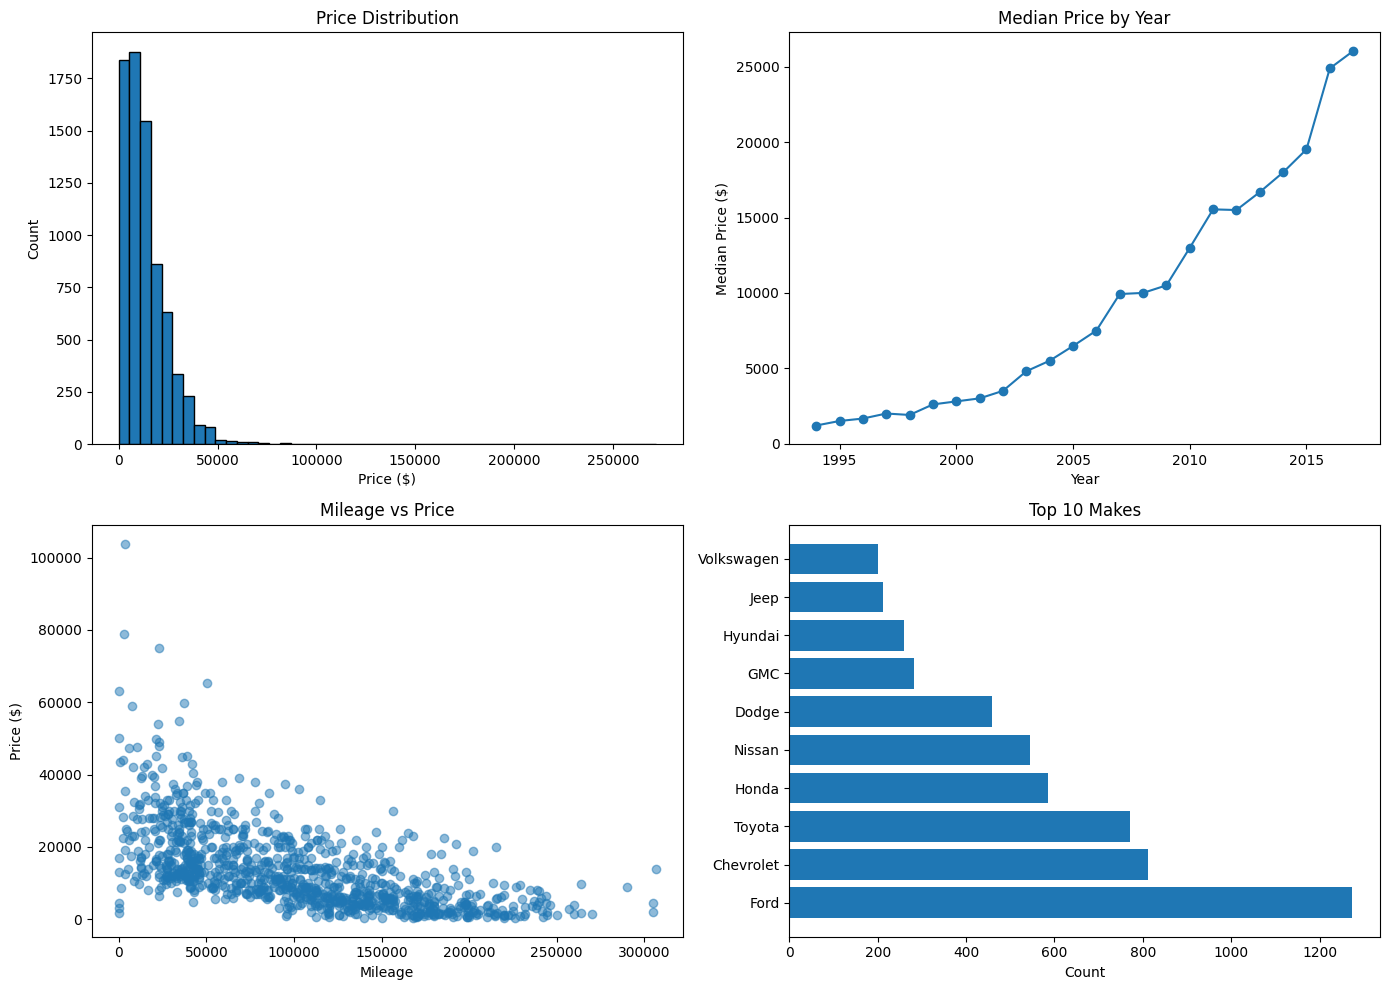

In [10]:
# B4: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(df_clean['Price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

# Year vs Price
year_price = df_clean.groupby('Year')['Price'].median()
axes[0, 1].plot(year_price.index, year_price.values, marker='o')
axes[0, 1].set_title('Median Price by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Median Price ($)')

# Mileage vs Price scatter
sample = df_clean.sample(min(1000, len(df_clean)))
axes[1, 0].scatter(sample['Mileage'], sample['Price'], alpha=0.5)
axes[1, 0].set_title('Mileage vs Price')
axes[1, 0].set_xlabel('Mileage')
axes[1, 0].set_ylabel('Price ($)')

# Top makes
top_makes = df_clean['Make'].value_counts().head(10)
axes[1, 1].barh(top_makes.index, top_makes.values)
axes[1, 1].set_title('Top 10 Makes')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [11]:
# B5: Simple Price Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features
model_df = df_clean[['Year', 'Make', 'Mileage', 'Body', 'Cylinders', 'Price']].dropna()

# Encode categorical variables
le_make = LabelEncoder()
le_body = LabelEncoder()
model_df['Make_encoded'] = le_make.fit_transform(model_df['Make'])
model_df['Body_encoded'] = le_body.fit_transform(model_df['Body'])

# Features and target
X = model_df[['Year', 'Mileage', 'Cylinders', 'Make_encoded', 'Body_encoded']]
y = model_df['Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.0f}")

# Feature importance
importance = pd.DataFrame({
    'Feature': ['Year', 'Mileage', 'Cylinders', 'Make', 'Body'],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance)

R² Score: 0.735
Mean Absolute Error: $3,184

Feature Importance:
     Feature  Importance
0       Year    0.363398
1    Mileage    0.245798
2  Cylinders    0.222082
4       Body    0.092555
3       Make    0.076166


---
## Interactive Dashboard

Filter and explore the car data with interactive controls.

In [17]:
# Install ipywidgets for interactive dashboard
%pip install ipywidgets -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Interactive Dashboard - Cascading Filters
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create widgets
make_dd = widgets.Dropdown(description='Make:', options=['All'] + sorted(df_clean['Make'].unique().tolist()))
model_dd = widgets.Dropdown(description='Model:', options=['All'])
year_dd = widgets.Dropdown(description='Year:', options=['All'])
body_dd = widgets.Dropdown(description='Body:', options=['All'])
view_dd = widgets.Dropdown(description='View:', options=['Bar Chart', 'Count Table'], value='Bar Chart')
output = widgets.Output()

def get_filtered_data():
    """Get data filtered by current selections"""
    filtered = df_clean.copy()
    if make_dd.value != 'All':
        filtered = filtered[filtered['Make'] == make_dd.value]
    if model_dd.value != 'All':
        filtered = filtered[filtered['Model'] == model_dd.value]
    if year_dd.value != 'All':
        filtered = filtered[filtered['Year'] == year_dd.value]
    if body_dd.value != 'All':
        filtered = filtered[filtered['Body'] == body_dd.value]
    return filtered

def update_models(*args):
    """When Make changes, update Model options"""
    filtered = df_clean if make_dd.value == 'All' else df_clean[df_clean['Make'] == make_dd.value]
    models = ['All'] + sorted(filtered['Model'].dropna().unique().tolist())
    model_dd.options = models
    model_dd.value = 'All'

def update_years(*args):
    """When Make/Model changes, update Year options"""
    filtered = df_clean.copy()
    if make_dd.value != 'All':
        filtered = filtered[filtered['Make'] == make_dd.value]
    if model_dd.value != 'All':
        filtered = filtered[filtered['Model'] == model_dd.value]
    years = ['All'] + sorted(filtered['Year'].unique().tolist())
    year_dd.options = years
    year_dd.value = 'All'

def update_bodies(*args):
    """When Make/Model/Year changes, update Body options"""
    filtered = df_clean.copy()
    if make_dd.value != 'All':
        filtered = filtered[filtered['Make'] == make_dd.value]
    if model_dd.value != 'All':
        filtered = filtered[filtered['Model'] == model_dd.value]
    if year_dd.value != 'All':
        filtered = filtered[filtered['Year'] == year_dd.value]
    bodies = ['All'] + sorted(filtered['Body'].dropna().unique().tolist())
    body_dd.options = bodies
    body_dd.value = 'All'

def update_dashboard(*args):
    """Render the dashboard"""
    with output:
        clear_output(wait=True)
        filtered = get_filtered_data()
        
        # Stats header
        if len(filtered) == 0:
            print("No vehicles match your filters.")
            return
            
        print(f"{'='*60}")
        print(f"  {len(filtered):,} vehicles")
        print(f"  Price: ${filtered['Price'].mean():,.0f} avg | ${filtered['Price'].median():,.0f} median")
        print(f"  Mileage: {filtered['Mileage'].mean():,.0f} avg miles")
        print(f"{'='*60}\n")
        
        if view_dd.value == 'Bar Chart':
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Left chart: counts by the most relevant grouping
            if make_dd.value == 'All':
                counts = filtered['Make'].value_counts().head(10)
                axes[0].barh(counts.index, counts.values, color='steelblue')
                axes[0].set_title('Top Makes')
            elif model_dd.value == 'All':
                counts = filtered['Model'].value_counts().head(10)
                axes[0].barh(counts.index, counts.values, color='steelblue')
                axes[0].set_title(f'{make_dd.value} Models')
            else:
                counts = filtered['Year'].value_counts().sort_index()
                axes[0].bar(counts.index, counts.values, color='steelblue')
                axes[0].set_title(f'{make_dd.value} {model_dd.value} by Year')
                axes[0].set_xlabel('Year')
            axes[0].set_xlabel('Count') if make_dd.value == 'All' or model_dd.value == 'All' else None
            
            # Right chart: price distribution
            if len(filtered) > 1:
                axes[1].hist(filtered['Price'], bins=20, color='coral', edgecolor='black')
                axes[1].axvline(filtered['Price'].median(), color='red', linestyle='--', label=f"Median: ${filtered['Price'].median():,.0f}")
                axes[1].set_title('Price Distribution')
                axes[1].set_xlabel('Price ($)')
                axes[1].legend()
            
            plt.tight_layout()
            plt.show()
            
        else:  # Count Table
            if make_dd.value == 'All':
                stats = filtered.groupby('Make')['Price'].agg(['count','mean','median']).round(0).astype(int)
            elif model_dd.value == 'All':
                stats = filtered.groupby('Model')['Price'].agg(['count','mean','median']).round(0).astype(int)
            else:
                stats = filtered.groupby('Year')['Price'].agg(['count','mean','median']).round(0).astype(int)
            
            stats.columns = ['Count', 'Avg $', 'Median $']
            stats = stats.sort_values('Count', ascending=False).head(20)
            print(stats.to_string())

# Wire up cascading updates
make_dd.observe(update_models, 'value')
make_dd.observe(update_years, 'value')
model_dd.observe(update_years, 'value')
make_dd.observe(update_bodies, 'value')
model_dd.observe(update_bodies, 'value')
year_dd.observe(update_bodies, 'value')

# Wire up dashboard refresh
for w in [make_dd, model_dd, year_dd, body_dd, view_dd]:
    w.observe(update_dashboard, 'value')

# Layout
row1 = widgets.HBox([make_dd, model_dd, year_dd, body_dd])
row2 = widgets.HBox([view_dd])
ui = widgets.VBox([row1, row2, output])

display(ui)
update_dashboard()

---
## Option C: Anthropic API in Notebook

Ask Claude to analyze data programmatically.

In [ ]:
# C1: Setup Anthropic Client
import anthropic
import os
from pathlib import Path

# Load API key from project .env file
env_path = Path.home() / "Projects" / "JD Agent" / ".env"
if env_path.exists():
    for line in env_path.read_text().splitlines():
        if line.startswith("ANTHROPIC_API_KEY="):
            os.environ["ANTHROPIC_API_KEY"] = line.split("=", 1)[1]
            break

client = anthropic.Anthropic()
print("✓ Anthropic client ready!")

In [13]:
# C2: Ask Claude to analyze the data summary
data_summary = f"""
Dataset: Used Car Listings
Rows: {len(df):,}
Columns: {list(df.columns)}

Statistics:
{df.describe().to_string()}

Missing Values:
{df.isnull().sum().to_string()}

Sample rows:
{df.head(5).to_string()}
"""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=1500,
    messages=[{
        "role": "user",
        "content": f"""Analyze this car dataset and provide:
1. Key data quality issues
2. Interesting patterns you notice
3. Recommended cleaning steps
4. Suggested analyses or models

{data_summary}"""
    }]
)

print("=== Claude's Analysis ===")
print(response.content[0].text)

TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [ ]:
# C3: Ask Claude to generate cleaning code
response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=2000,
    messages=[{
        "role": "user",
        "content": f"""Write Python/pandas code to clean this car dataset. 
Handle missing values, outliers, and prepare it for price prediction modeling.
Return only executable code with comments.

Columns: {list(df.columns)}
Missing values: {df.isnull().sum().to_dict()}
Price range: ${df['Price'].min():,} - ${df['Price'].max():,}
Mileage range: {df['Mileage'].min():,} - {df['Mileage'].max():,}"""
    }]
)

print("=== Claude's Cleaning Code ===")
print(response.content[0].text)

In [ ]:
# C4: Ask Claude for modeling recommendations
# After cleaning, get model recommendations

correlation_info = df_clean[['Year', 'Price', 'Mileage', 'Cylinders']].corr().to_string()

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=1500,
    messages=[{
        "role": "user",
        "content": f"""Based on this correlation matrix and data characteristics, 
recommend the best ML model for predicting car prices and explain why.

Correlation matrix:
{correlation_info}

Data characteristics:
- {len(df_clean):,} samples after cleaning
- Numeric features: Year, Mileage, Cylinders
- Categorical features: Make ({df_clean['Make'].nunique()} unique), Model, Body, Condition
- Target: Price (median ${df_clean['Price'].median():,.0f})"""
    }]
)

print("=== Claude's Modeling Recommendations ===")
print(response.content[0].text)

---
## Comparison Summary

| Approach | Best For | Pros | Cons |
|----------|----------|------|------|
| **Option A** (Claude Code) | Quick analysis, exploration | Fast, conversational, sees your files | Manual copy/paste for large data |
| **Option B** (Manual + Claude) | Production code, learning | Full control, reproducible | Need to know pandas/sklearn |
| **Option C** (API in notebook) | Automated pipelines, dynamic analysis | Programmatic, flexible prompts | API costs, latency |